# CPU chi-square fixes on recorded LIGO Hanford data

PyCBC tests how consistently a candidate signal matches its template across frequency bins. Its selected-time CPU routine rotates and sums frequency coefficients. This notebook compares **three independent patches and their combination** against the same upstream code and an independent reference.

The replay contains all three selected samples from one recorded call: public H1 strain, 2048 Hz, a 512-second segment, 16 chi-square bins and a 32-template IMRPhenomD qualification search. Capture 5 was selected for the largest discrepancy among six saved calls (11 samples). **This selection cannot estimate how common the error is.** Conditioning, correlation, bin edges, SNR and normalization are held fixed; the CPU routine under test performs no FFT.

Run from this directory after following [README](README.md). The helper compiles archived Cython sources with PyCBC's build flags; it is not an arithmetic model. [Capture provenance](../data/point-input-05.json) · [related upstream work](existing_work.md).

In [1]:
import warnings
warnings.filterwarnings("ignore", message="Wswiglal-redir-stdio:")

import json
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.fft import ifft
from pycbc.types import Array
from pycbc.events.ranking import newsnr
from cpu_chisq_review import kernels, load_capture, reference_power, plot_style

plot_style()
modules = kernels()
data = load_capture()
corr, snr = data['corr'], data['snr']
points, bins = data['indices'], data['bins']
norm = float(data['norm'])
N, p = len(corr), len(bins) - 1
snr_power = (snr.conj() * snr).real
manifest = json.loads(Path('kernels/manifest.json').read_text())
print('Upstream source:', manifest['upstream_commit'])
print('Samples:', points.tolist(), '; widest bin:', int(np.diff(bins).max()))
assert np.array_equal(points, points.astype(np.float32).astype(points.dtype))
print('All captured indices are exactly representable as float32.')

Upstream source: 454ee900e6faca88a066e71ade489fca9fb221a5
Samples: [484954, 619888, 656106] ; widest bin: 373308
All captured indices are exactly representable as float32.


## Independent reference and actual before/after results

Let qᵦ be the rotated sum in bin b, S = Σᵦ|qᵦ|², and p the number of bins. The statistic is **χ² = (p S − |snr|²) × norm²**. Here `snr` is the captured unnormalized matched-filter sum and `norm` its SNR normalization. The reference evaluates every phase explicitly in complex128 and checks against separate complex128 inverse FFTs. Both preserve the captured SNR-power term, so this evaluates the selected-point stage, not every source of numerical error in a search.

The patch results below retain the actual float32 output and final wrapper arithmetic for complex64 inputs. `verify_installed.py` checked these expressions and archived-kernel outputs against each built checkout's public PyCBC call.

In [2]:
reference = reference_power(corr, points, bins)
fft_power = np.zeros(len(points))
for lo, hi in zip(bins[:-1], bins[1:]):
    band = np.zeros(N, dtype=np.complex128)
    band[lo:hi] = corr[lo:hi]
    fft_power += abs((N * ifft(band))[points])**2
np.testing.assert_allclose(reference, fft_power, rtol=1e-11)
reference_chisq = (p * reference - snr_power) * norm**2
value = Array(corr, copy=False)
powers = {label: module.shift_sum(value, points, bins)
          for label, module in modules.items()}
chisq = {label: (p * power - snr_power) * norm**2
         for label, power in powers.items()}
errors = {label: 100 * (chi / reference_chisq - 1)
          for label, chi in chisq.items()}
np.testing.assert_array_equal(chisq['shifts'], chisq['upstream'])
np.testing.assert_allclose(chisq['combined'], reference_chisq, rtol=5e-7)
table = pd.DataFrame(errors, index=points)
table.index.name = 'sample'
table.insert(0, 'reference chi-square', reference_chisq)
print('Remaining columns: signed chi-square error (% of reference).')
display(table.style.format(precision=7))
print('Max |direct / FFT reference difference|:',
      np.max(abs(reference / fft_power - 1)))

Remaining columns: signed chi-square error (% of reference).


,reference chi-square,upstream,pi,shifts,arithmetic,combined
sample,,,,,,
484954,33.3259417,-0.0281664,-0.0285441,-0.0281664,-0.0001679,-0.0000077
619888,36.3370953,-0.1503483,-0.1492880,-0.1503483,-0.0002152,0.0000052
656106,42.9809734,0.1721608,0.1738914,0.1721608,0.0005033,0.0000062


Max |direct / FFT reference difference|: 2.220446049250313e-16


## Independent patches and their combined effect

These curves use **compiled kernels**, adding complete bins from left to right. Each y-value is the accumulated bin-power discrepancy's contribution to the **final** reference χ²; it is not a partial χ² statistic. The endpoint isolates kernel error by using common float64 final arithmetic. The table above also includes public-wrapper rounding.

The upper panel shows remaining error after each patch. The lower panel compares the joint correction with the sum of three separate corrections. Their difference measures interaction between patches; the corrections need not add. This does not allocate the arithmetic patch's improvement between phase and summation. Those mechanisms have separate [phase](phase.ipynb) and [accumulation](accumulation.ipynb) examples.

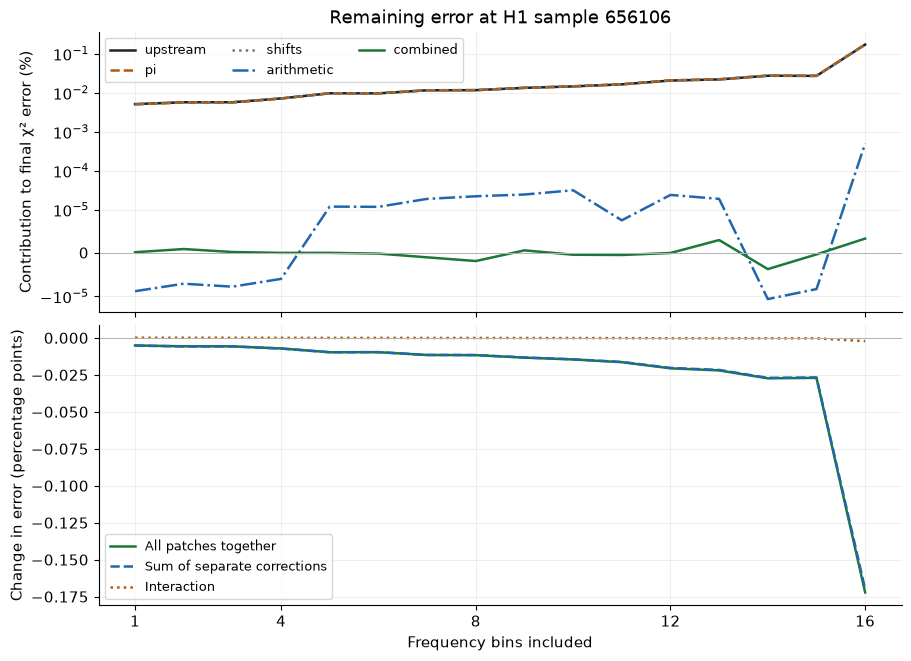

In [3]:
reference_bins = np.array([reference_power(corr, points, bins[j:j+2])
                           for j in range(p)]).T
reference_cumulative = np.cumsum(reference_bins, axis=1)
cumulative = {label: np.column_stack([
    module.shift_sum(value, points, bins[:j+2]) for j in range(p)])
    for label, module in modules.items()}
contribution = {label: 100*p*norm**2*(power-reference_cumulative) /
                reference_chisq[:, None] for label, power in cumulative.items()}
j = int(np.flatnonzero(points == 656106)[0])
x = np.arange(1, p+1)
colors = {'upstream':'#222222', 'pi':'#b35806', 'shifts':'#777777',
          'arithmetic':'#2166ac', 'combined':'#1b7837'}
styles = {'upstream':'-', 'pi':'--', 'shifts':':',
          'arithmetic':'-.', 'combined':'-'}
fig, axes = plt.subplots(2, 1, figsize=(9, 6.5), sharex=True, layout='constrained')
for label in modules:
    axes[0].plot(x, contribution[label][j], label=label,
                 color=colors[label], ls=styles[label])
axes[0].set_title('Remaining error at H1 sample 656106')
axes[0].set_yscale('symlog', linthresh=1e-5)
axes[0].set_ylabel('Contribution to final χ² error (%)')
axes[0].legend(ncol=3, fontsize=9)
separate = sum(contribution[label] - contribution['upstream']
               for label in ['pi', 'shifts', 'arithmetic'])
joint = contribution['combined'] - contribution['upstream']
interaction = joint - separate
np.testing.assert_allclose(joint, separate + interaction, atol=1e-14)
axes[1].plot(x, joint[j], label='All patches together', color='#1b7837')
axes[1].plot(x, separate[j], '--', label='Sum of separate corrections', color='#2166ac')
axes[1].plot(x, interaction[j], ':', label='Interaction', color='#b35806')
axes[1].set(xlabel='Frequency bins included', ylabel='Change in error (percentage points)',
            xticks=[1,4,8,12,16])
axes[1].legend(fontsize=9)
for ax in axes:
    ax.axhline(0, color='0.7', lw=.7)
plt.show()

## Could candidate selection change?

Chi-square feeds reweighted SNR (NewSNR). Recompute that statistic using the captured SNR and the same threshold of 5. This is an observed per-candidate consequence of the replay, not a sensitivity or false-alarm study. A different near-threshold candidate could change selection if its score moved across the cut; this sample cannot establish how often that happens.

In [4]:
rho = abs(snr) * norm
scores = {label: newsnr(rho, chi / (2*p-2)) for label, chi in chisq.items()}
scores['reference'] = newsnr(rho, reference_chisq / (2*p-2))
selection = pd.DataFrame({
    'SNR': rho, 'upstream NewSNR': scores['upstream'],
    'combined NewSNR': scores['combined'], 'reference NewSNR': scores['reference'],
    'score change': scores['combined'] - scores['upstream'],
    'upstream passes 5': scores['upstream'] >= 5,
    'combined passes 5': scores['combined'] >= 5}, index=points)
selection.index.name = 'sample'
display(selection.style.format(precision=7))
print('Candidates crossing threshold in this replay:',
      np.count_nonzero((scores['upstream'] >= 5) != (scores['combined'] >= 5)))

,SNR,upstream NewSNR,combined NewSNR,reference NewSNR,score change,upstream passes 5,combined passes 5
sample,,,,,,,
484954,5.5250125,5.3710216,5.3705844,5.3705843,-0.0004372,True,True
619888,5.5640130,5.2703499,5.2678153,5.2678154,-0.0025346,True,True
656106,5.5534453,4.9566842,4.9598684,4.9598685,0.0031843,False,False


Candidates crossing threshold in this replay: 0


## Accuracy and CPU cost

Double working precision retains compact complex64 input storage and the existing output dtype. The timings below measure the pointwise kernel, excluding input construction, on one host. Nine interleaved batches report median and interquartile range; they do not predict end-to-end search runtime. [Full timings](benchmark.csv), [environment](benchmark_environment.json), and `python benchmark.py` make the comparison reproducible. Short, uniform, captured and wider-bin workloads cover both dtypes and 1, 2 and 5 selected samples.

In [5]:
timings = pd.read_csv('benchmark.csv')
selected = timings[(timings['shape'] == 'captured') &
                   (timings['dtype'] == 'complex64') &
                   timings['variant'].isin(['upstream', 'arithmetic', 'combined'])]
display(selected[['npoints', 'variant', 'median_ms', 'q25_ms', 'q75_ms',
                  'ratio_to_upstream']].style.format(precision=3))

,npoints,variant,median_ms,q25_ms,q75_ms,ratio_to_upstream
60,1,upstream,1.063,1.039,1.087,1.000
63,1,arithmetic,1.099,1.084,1.121,1.035
64,1,combined,1.073,1.059,1.102,1.010
65,2,upstream,1.858,1.838,1.926,1.000
68,2,arithmetic,1.168,1.123,1.188,0.628
69,2,combined,1.131,1.118,1.140,0.609
70,5,upstream,1.746,1.670,1.915,1.000
73,5,arithmetic,2.453,2.434,2.493,1.405
74,5,combined,2.475,2.464,2.494,1.417


The index patch is inactive for these short segments. The arithmetic patch reduces the large recurrence/accumulation discrepancy but leaves the independent π approximation; the combined result also removes that bias. Remaining float32 output and wrapper rounding are visible. No result here demonstrates changes in astrophysical detection efficiency, population inference, or false-alarm rates.